# Axe 1 : Qui part ?

---

Dans ce notebook, j'étudie les variables liées aux caractéristiques personnelles des employés afin d’identifier leurs relations potentielles avec l’attrition.

Ce notebook a pour objectif :

- d'explorer les variables de l'axe,
- de les comparer à l'attrition
- d'analyser les relations internes à l'axe
- de visualiser et mettre en évidence les relations les plus structurantes.

## 1. Préparation des données de l’axe

---

Dans cette section, les variables nécessaires à l'analyse de l'axe conditions personnelles sont sélectionnées et préparées à partir du jeu de données nettoyé.
Les transformations réalisées sont spécifiques à cet axe.

### 1.1 Import des librairies et chargement des données



In [2]:
# import librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display_html

from pathlib import Path

In [3]:
# Définition des chemins

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

In [4]:
# chargement du df
df_clean = pd.read_parquet(PROCESSED_DATA_DIR/"employees_clean.parquet")
df_clean.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


### 1.2 Fonctions utilitaires


In [5]:
# Tableau de pourcentage variable univarié

def value_counts_percent(serie,round_n=3):

    """  Calcule la distribution (%) d'une variable catégorielle et retourne un DataFrame"""
    
    return (serie.value_counts(normalize=True).
            round(round_n).
            mul(100).
            reset_index(name="Pourcentage"))

# Tableau de pourcentage de variables bivariés
def groupby_percent(df,columns1,columns2,observed=True):
    """Calcule la distribution (%) de columns2 pour chaque modalité de columns1
    et retourne un DataFrame au format long. """
    return(df.groupby(columns1,observed=observed)[columns2].
           value_counts(normalize=True).
           round(3)
           *100).reset_index(name="Pourcentage")


# Table pivot en pourcentage de variables bivarié
def pivot_percent(df,index,columns):
    """ Crée un tableau pivot (%) : lignes=index, colonnes=columns."""
    df = groupby_percent(df,index,columns)
    return(df.pivot(index=index, columns=columns,values="Pourcentage").fillna(0))


### 1.3 Construction et préparation du DataFrame conditions_personnelle

#### Colonnes incluses dans l'axe "Conditions personnelles"

Cet axe regroupe les caractéristiques individuelles :

- âge  
- situation familiale  
- genre  
- niveau d'éducation
- domaines d'éducation
- mobilité géographique  
- mobilité professionnelle

Ces variables donnent un contexte personnel susceptible influencer l'attrition.

In [6]:
# colonnes condition_perso
col_conditions_perso = ['Age', 'DistanceFromHome','Education','EducationField','Gender','MaritalStatus','NumCompaniesWorked',"EmployeeNumber"]

# Création df_condition_personnelles
df_conditions_personnelles = df_clean[col_conditions_perso + ['Attrition']].copy()
df_conditions_personnelles.head(3)

,Age,DistanceFromHome,Education,EducationField,Gender,MaritalStatus,NumCompaniesWorked,EmployeeNumber,Attrition
0,41,1,2,Life Sciences,Female,Single,8,1,Yes
1,49,8,1,Life Sciences,Male,Married,1,2,No
2,37,2,2,Other,Male,Single,6,4,Yes


#### Préparation des variables

Objectif : créer des variables explicites (labels) et harmoniser les échelles ordinales.

**Actions :**
- Renommage pour la lisibilité
- Création de tranches
- Regroupements : Les seuils de regroupement peuvent différer selon les sous-thèmes afin de s'adapter à la distribution spécifique de chaque variable et à leur interprétation métier.

**Création des tranches d'âge (Age)**

L'âge est une variable continue peu lisible en l'état.  
Pour faciliter l'analyse et observer des tendances plus nettes, je regroupe les employés en classes d'âge cohérentes du point de vue RH :

- **18-25 ans** : début de carrière, forte mobilité
- **26-35 ans** : stabilisation professionnelle, construction familiale
- **36-45 ans** : maturité professionnelle
- **46-55 ans** : employés expérimentés
- **55+ ans** : fin de carrière

Ces tranches permettront d'étudier plus clairement la relation entre âge et attrition.


In [7]:
# Création tranche d'age
df_conditions_personnelles["Tranche_Age"] = pd.cut(
    df_conditions_personnelles["Age"],
    bins=[0 , 25, 35, 45, 55, 150],
    labels=["18-25", "26-35", "36-45", "46-55", "+55"],
    ordered=True,
    include_lowest=True)

df_conditions_personnelles["Tranche_Age"].head(2)

0    36-45
1    46-55
Name: Tranche_Age, dtype: category
Categories (5, object): ['18-25' < '26-35' < '36-45' < '46-55' < '+55']

**Regroupement distance domicile-travail (DistanceFromHome)**

Pour faciliter l'analyse exploratoire et rendre les visualisations plus lisibles, la distance est regroupée en tranches cohérentes :

- **1-5 km** : très proche  
- **6-10 km** : proche  
- **11-20 km** : distance moyenne  
- **> 20 km** : éloigné  

Ces catégories permettent d'identifier plus facilement d'éventuelles relations entre la distance domicile-travail et l'attrition.


In [8]:
# Création des regroupements

df_conditions_personnelles['Tranche_Distance'] = pd.cut(
    df_conditions_personnelles['DistanceFromHome'],
    bins = [0, 5, 10, 20, 30],
    labels= ["1-5", "6-10", "11-20", ">20"],
    include_lowest=True,
    ordered=True)

df_conditions_personnelles["Tranche_Distance"].head(2)

0     1-5
1    6-10
Name: Tranche_Distance, dtype: category
Categories (4, object): ['1-5' < '6-10' < '11-20' < '>20']

**Renommage des niveaux d'éducation (Education)**

Les niveaux d'éducation sont initialement codés sous forme numérique (1 à 5). Pour faciliter la lecture et l'analyse, je remplace ces codes par des catégories explicites 
Cette transformation permet d'interpréter facilement la répartition des employés selon leur niveau d'étude.


In [9]:
niveau_education = {
    1 : 'Below College',
    2 : 'College',
    3 : 'Bachelor',
    4 : 'Master',
    5 : 'Doctor'}

df_conditions_personnelles["Education_label"] = df_conditions_personnelles['Education'].replace(niveau_education)
df_conditions_personnelles.head(2)

,Age,DistanceFromHome,Education,EducationField,Gender,MaritalStatus,NumCompaniesWorked,EmployeeNumber,Attrition,Tranche_Age,Tranche_Distance,Education_label
0,41,1,2,Life Sciences,Female,Single,8,1,Yes,36-45,1-5,College
1,49,8,1,Life Sciences,Male,Married,1,2,No,46-55,6-10,Below College


**Renommage des genres (Gender)**

La variable `Gender` utilise des codes bruts (`Male`, `Female`).  
Je les remplace par des libellés plus explicites (*Homme* et *Femme*) afin d'améliorer la lisibilité et la cohérence du jeu de données.

In [10]:
df_conditions_personnelles["Gender"] = df_conditions_personnelles["Gender"].replace({"Male": "Homme","Female": "Femme"})

df_conditions_personnelles.head(2)

,Age,DistanceFromHome,Education,EducationField,Gender,MaritalStatus,NumCompaniesWorked,EmployeeNumber,Attrition,Tranche_Age,Tranche_Distance,Education_label
0,41,1,2,Life Sciences,Femme,Single,8,1,Yes,36-45,1-5,College
1,49,8,1,Life Sciences,Homme,Married,1,2,No,46-55,6-10,Below College


**Regroupement du nombre d'entreprises précédemment travaillées (NumCompaniesWorked)**

Pour faciliter l'analyse exploratoire et rendre les visualisations plus lisibles, le nombre d'entreprises précédemment travaillées est regroupé en tranches cohérentes :

- **0-1 entreprise** : employés très stables ou débutants  
- **2-3 entreprises** : employés ayant une mobilité modérée  
- **4-6 entreprises** : employés ayant une mobilité élevée  
- **7+ entreprises** : employés ayant une forte instabilité ou une carrière très variée  

Ces catégories permettent d'identifier plus facilement d'éventuelles relations entre le nombre d'entreprises précédemment travaillées et l'attrition.


In [11]:
df_conditions_personnelles['Tranche_EtsTravaille'] = pd.cut(
    df_conditions_personnelles['NumCompaniesWorked'],
    bins= [0, 1, 3, 6, 10],
    labels= ["0-1", "2-3", "4-6", "+7"],
    ordered=True,
    include_lowest=True
)

df_conditions_personnelles["Tranche_EtsTravaille"].head(2)

0     +7
1    0-1
Name: Tranche_EtsTravaille, dtype: category
Categories (4, object): ['0-1' < '2-3' < '4-6' < '+7']

### 1.4 Sauvegarde du DataFrame

In [12]:
df_conditions_personnelles.to_parquet(PROCESSED_DATA_DIR/"df_conditions_personnelles.parquet",index=False)

## 2. Analyse individuelle des variables : Profil de la population

---

Dans cette section, l'analyse porte sur plusieurs caractéristiques personnelles des employés afin de mieux comprendre la composition de la population étudiée.

Les variables sont : âge, genre, situation familiale, niveau et domaine d'éducation, distance domicile-travail et mobilité professionnelle.

Elles sont présentées successivement pour décrire la composition de la population étudiée.

Certaines variables sont analysées de manière plus approfondie que d'autres.
Cette analyse repose sur une approche **descriptive**, basée sur l'étude des **distributions**, à l'aide de **tableaux de proportions** et, lorsque pertinent, de **visualisations graphiques**.

Dans un souci de lisibilité, seules les variables présentant une structuration visuelle claire ou une diversité suffisante des modalités font l'objet de représentations graphiques.

### 2.1 Âge


**Tableau des proportions**

In [13]:

age_count = value_counts_percent(df_conditions_personnelles["Tranche_Age"])
age_count

,Tranche_Age,Pourcentage
0,26-35,41.2
1,36-45,31.8
2,46-55,15.4
3,18-25,8.4
4,+55,3.2


**Analyse de la distribution de l'âge des employés**

Ce graphique montre la répartition des employés selon les tranches d'âge.  

On observe que deux tranches d'age sont particulièrement représentées : 

- **26-35 ans** (≈ 41 %),
- **36-45 ans**(≈ 32 %)

Ces tranches représentent la majorité de la population active de l'entreprise.

Les tranches : 

- **18-25 ans** et **46-55 ans** sont moins représentées,  
- tandis que les **55+** sont très minoritaires (≈ 3 %).

La visualisation ci-dessous permet de confirmer ces observations.

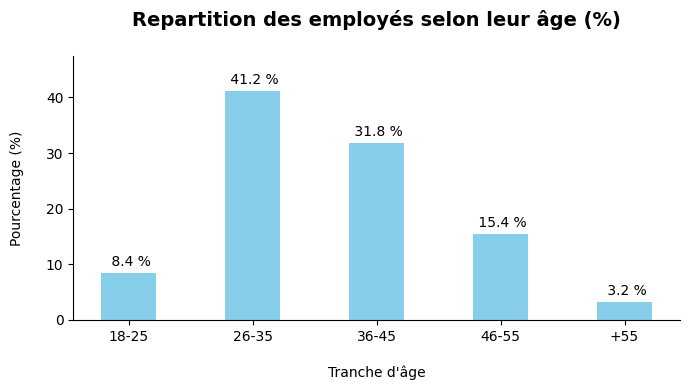

(None,)

In [14]:
# Trier
age_count = age_count.sort_values("Tranche_Age",ascending=True)

fig , ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(age_count.index))
y = age_count.Pourcentage

# Bar plot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Affiché pourcentage
ax.bar_label(bars, labels=[f"{v : .1f} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(age_count["Tranche_Age"])

ax.set_ylim(0, max(y) * 1.15)

ax.set_xlabel("\nTranche d'âge")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Repartition des employés selon leur âge (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

### 2.2 Distance domicile-Travail `DistanceFromHome`

J'analyse ici la répartition des employés selon la mobilité géographique, afin d'identifier les niveaux de proximité les plus fréquents dans l'entreprise.

**Tableau des proportions**


In [15]:
distanceFromHome_count = value_counts_percent(df_conditions_personnelles["Tranche_Distance"])
distanceFromHome_count

,Tranche_Distance,Pourcentage
0,1-5,43.0
1,6-10,26.8
2,11-20,16.3
3,>20,13.9


**Analyse de la distribution des employés par distance domicile-travail**

On observe que les employés habitant **très près ou relativement proches** de leur lieu de travail représentent la majorité de l'effectif, avec **près de 70 %** situés à moins de 10 km.  

À l'inverse, les personnes résidant à plus de 20 km restent minoritaires (≈14 %).

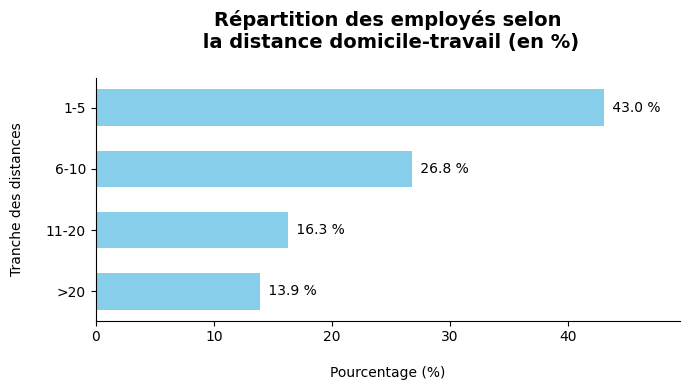

(None,)

In [16]:
# Trier
distanceFromHome_count = distanceFromHome_count.sort_values("Tranche_Distance", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(distanceFromHome_count.index))
y = distanceFromHome_count["Pourcentage"]

# Barplot
barhs = ax.barh(x, y, height=0.6, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels
ax.invert_yaxis()
ax.set_yticks(x)
ax.set_yticklabels(distanceFromHome_count["Tranche_Distance"])

ax.set_xlim(0, max(y) * 1.15)
ax.set_xlabel("\nPourcentage (%)")
ax.set_ylabel("Tranche des distances\n")
ax.set_title("Répartition des employés selon\n la distance domicile-travail (en %)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

### 2.3 Niveau d'éducation `Education`

**Tableau des proportions**

In [17]:
Education_count = value_counts_percent(df_conditions_personnelles["Education_label"])
Education_count

,Education_label,Pourcentage
0,Bachelor,38.9
1,Master,27.1
2,College,19.2
3,Below College,11.6
4,Doctor,3.3


On observe qu'un peu plus de la moitié des employés ont un niveau **Bachelor** (≈39 %) ou **Master** (≈27 %). 
 
Environ 30 % présentent un niveau College ou Below College, tandis qu'une minorité (≈3 %) ont atteint le niveau Doctorat.

### 2.4 Domaine d'éducation `EducationField`

J'analyse ici la répartition des employés selon leur domaine d'éducation (`EducationField`).  
Cette variable permet d'identifier les disciplines académiques les plus représentées dans l'entreprise et d'observer la diversité des parcours.

**Tableau des proportions**

In [18]:
educationField_count = value_counts_percent(df_conditions_personnelles["EducationField"])
educationField_count

,EducationField,Pourcentage
0,Life Sciences,41.2
1,Medical,31.6
2,Marketing,10.8
3,Technical Degree,9.0
4,Other,5.6
5,Human Resources,1.8



On observe que deux domaines d'éducation sont particulièrement représentés : 

- **Life Sciences** (≈ 41 %)  
- **Médical** (≈ 32 %)

Les domaines plus minoritaires sont **Other** (≈ 5 %) et **Human Resources** (≈ 2 %).

Cette exploration permet d'avoir une première vision des types de parcours académiques présents dans l'entreprise et d'apprécier la diversité des profils.

### 2.5 Genre
 
Cette variable permet d'observer la composition de la population en termes de diversité et d'équilibre homme-femmes.

**Tableau des proportions**

In [19]:
gender_count = value_counts_percent(df_conditions_personnelles["Gender"])
gender_count

,Gender,Pourcentage
0,Homme,60.0
1,Femme,40.0


La répartition homme-femmes est relativement équilibrée dans l'entreprise, avec **une légère majorité d'hommes** représentant 60 % de l'effectif.


### 2.6 Statut marital `MaritalStatus`

J'analyse ici la répartition des employés selon leur statut marital, afin d'identifier les situations familiales les plus représentées dans l'entreprise.

**Tableau des proportions**

In [20]:
maritalStatus_count = value_counts_percent(df_conditions_personnelles["MaritalStatus"])
maritalStatus_count

,MaritalStatus,Pourcentage
0,Married,45.8
1,Single,32.0
2,Divorced,22.2


**Analyse de la distribution des employées selon leur statut marital**

Ce graphique montre que le statut marital le plus représenté est **Married** (≈ 46 %).  

Le statut **Single** concerne environ 32 % des employés, tandis que **Divorced** représente près de 22 %.

Cette exploration permet d'obtenir une première vision des situations familiales présentes dans l'entreprise.

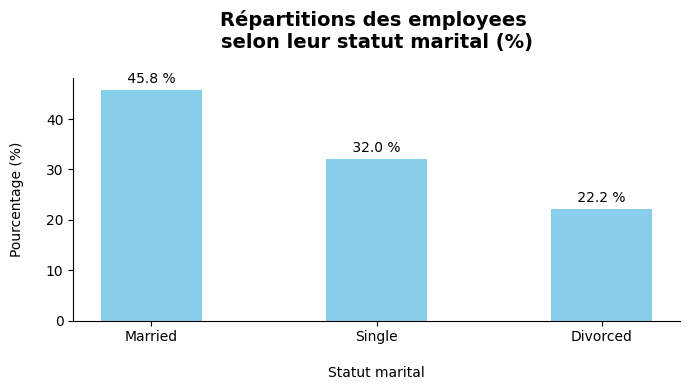

(None,)

In [21]:

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(maritalStatus_count.index))
y = maritalStatus_count["Pourcentage"]

# Bar plot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(maritalStatus_count["MaritalStatus"])

ax.set_xlabel("\nStatut marital")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Répartitions des employees \nselon leur statut marital (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),


### 2.7 la mobilité professionnelle `NumCompaniesWorked`

J'analyse ici la répartition des employés selon leur mobilité professionnelle passée.  

Cette variable permet d'observer le niveau de stabilité professionnelle des employés.

**Tableau des proportions**

In [22]:
numCompaniesWorked_count = value_counts_percent(df_conditions_personnelles["Tranche_EtsTravaille"])
numCompaniesWorked_count

,Tranche_EtsTravaille,Pourcentage
0,0-1,48.8
1,2-3,20.7
2,4-6,18.5
3,+7,11.9


**Analyse de la distribution des employés selon le nombre d'entreprises travaillés précédemment**

On observe que les employés présentant une mobilité professionnelle **faible à modérée** représentent la majorité de l'effectif, avec près de **65 %** des employés ayant travaillé au maximum de plus de trois entreprises.  

À l'inverse, les profils présentant une forte instabilité ou une carrière très variée restent minoritaires (≈14 %).

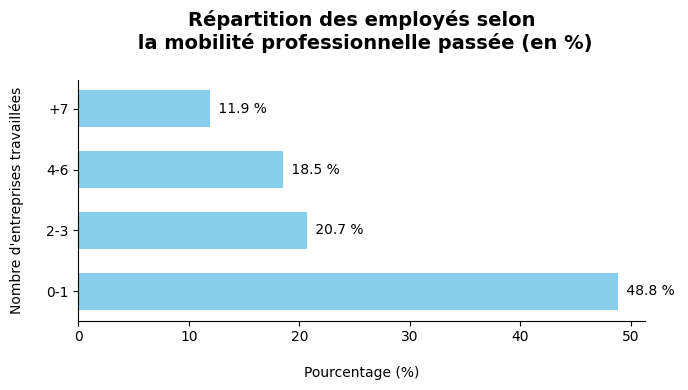

(None,)

In [23]:

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(numCompaniesWorked_count.index))
y = numCompaniesWorked_count["Pourcentage"]

# Barplot
barhs = ax.barh(x, y, height=0.6, color="skyblue")

# Pourcentage affiché
ax.bar_label(barhs, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_yticks(x)
ax.set_yticklabels(numCompaniesWorked_count["Tranche_EtsTravaille"])

ax.set_xlabel("\nPourcentage (%)")
ax.set_ylabel("Nombre d'entreprises travaillées\n")
ax.set_title("Répartition des employés selon\n la mobilité professionnelle passée (en %)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

### 2.8 Mini-synthèse — Caractéristiques personnelles


L'analyse descriptive met en évidence une population majoritairement composée de salariés d'âge intermédiaire, avec une présence plus limitée de salariés plus jeunes et plus âgés.

Les situations familiales et les niveaux d'éducation présentent une répartition diversifiée, sans domination exclusive d'une modalité.

En revanche, les variables liées à la mobilité, telles que le nombre d'entreprises précédemment occupées et la distance domicile-travail, montrent des répartitions plus contrastées au sein de l'effectif étudié.

Cette analyse individuelle permet de mieux comprendre la composition de la population étudiée selon les caractéristiques personnelles.  

La section suivante s'intéresse désormais aux relations entre ces variables et l'attrition.

## 3. Attrition - Conditions personnelles

---

### 3.1 Introduction

Dans cette section, j'analyse la relation entre l'attrition et les caractéristiques personnelles des employés.

L'analyse s'appuie sur le **taux d'attrition global (≈16 %)** comme niveau de référence, puis sur **des tableaux de proportions** et, lorsque cela apporte une lecture plus immédiate, **des visualisations graphiques**, afin de comparer les taux d'attrition entre groupes.

Les résultats doivent être interprétés comme des indicateurs de sur- ou sous-exposition, et non comme des relations causales.


#### Tableau de proportions Attrition Yes / No


In [24]:
attrition_count = value_counts_percent(df_conditions_personnelles['Attrition'])

attrition_count

,Attrition,Pourcentage
0,No,83.9
1,Yes,16.1


D'après ce tableau, le taux d'attrition global observé dans le jeu de données est d'environ **16 %**, ce qui constitue le niveau de référence pour les analyses suivantes.

Dans les analyses suivantes, l'accent est mis sur le taux d'attrition (Attrition = Yes), les non-départs représentant le complément à 100 %.

### 3.2 Analyse de l'attrition selon les variables des conditions personnelles

Les variables ont d'abord été explorées individuellement. Dans cette section, je me concentre sur celles présentant des écarts de taux d'attrition suffisamment lisibles pour permettre une comparaison pertinente.

Les variables sont présentées selon leur degré de différenciation du taux d'attrition observé, afin de mettre en évidence les facteurs les plus discriminants.

Cette approche descriptive permet de mettre en évidence des profils plus ou moins exposés à l'attrition, sans chercher à expliquer directement les mécanismes de départ.


#### 3.2.1 Attrition et âge

Dans cette section, je compare l'attrition selon les tranches d'âge afin d'observer si le taux d'attrition varie en fonction de l'âge des employés.

**Tableau de proportions**


In [25]:
# Tableau de proportion
age_attrition = df_conditions_personnelles[["Tranche_Age", "Attrition"]]

## pivot : ligne = tranche d'age, colonne= attrition, valeur =pourcentage
pivot_age_attrition = pivot_percent(age_attrition, "Tranche_Age","Attrition")
pivot_age_attrition

Attrition,No,Yes
Tranche_Age,,
18-25,64.2,35.8
26-35,80.9,19.1
36-45,90.8,9.2
46-55,88.5,11.5
+55,83.0,17.0


**Analyse de la relation entre la tranche d'âge et l'attrition**

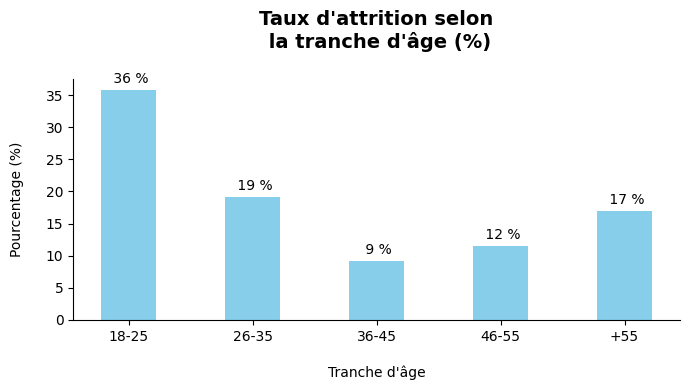

(None,)

In [26]:
fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(pivot_age_attrition.index))
y = pivot_age_attrition["Yes"]

# barplot
bars = ax.bar(x, y, color="skyblue", width=0.45)

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .0F} %' for v in y ], padding=3)

# axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_age_attrition.index)
ax.set_xlabel("\nTranche d'âge")
ax.set_ylabel("Pourcentage (%)\n")
ax.set_title("Taux d'attrition selon\n la tranche d'âge (%)\n",fontweight="bold", fontsize=14)

fig.tight_layout()
plt.show(),

On observe que le taux d'attrition varie selon l'âge.  

La tranche **18-25 ans** présente le taux d'attrition le plus élevé (≈36 %).  

À l'inverse, les tranches **36-45 ans** et **46-55 ans** affichent les taux les plus faibles (≈9 % et ≈12 %).
  
Les tranches **26-35 ans** et **+55 ans** se situent à un niveau intermédiaire (≈19 % et ≈17 %).


#### 3.2.2 Attrition et mobilité professionnelle

Dans cette section, j'analyse la relation entre l'attrition et la mobilité professionnelle passée des employés, mesurée par le nombre d'entreprises précédemment travaillées, afin d'observer si le taux d'attrition varie selon le niveau de mobilité.

**Tableau de proportions**

In [27]:
# Tableau de proportion
numCompaniesWorked_attrition = df_conditions_personnelles[["Tranche_EtsTravaille", "Attrition"]]

## pivot : ligne = tranche Entreprise travaillée, colonne= attrition, valeur =pourcentage
pivot_numCompaniesWorked_attrition = pivot_percent(numCompaniesWorked_attrition, "Tranche_EtsTravaille","Attrition")
pivot_numCompaniesWorked_attrition

Attrition,No,Yes
Tranche_EtsTravaille,,
0-1,83.1,16.9
2-3,89.5,10.5
4-6,82.0,18.0
+7,80.0,20.0


**Analyse de la relation entre la mobilité professionnelle et l'attrition**

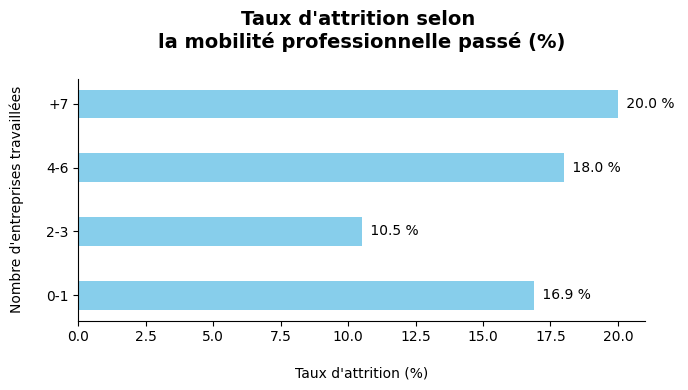

(None,)

In [28]:
fig, ax = plt.subplots(figsize=(7,4))

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

#  Données

x = np.arange(len(pivot_numCompaniesWorked_attrition.index))
y = pivot_numCompaniesWorked_attrition['Yes']

# Barplot
bars = ax.barh(x, y, height=0.45, color="skyblue")

# Affiché pourcentage
ax.bar_label(bars, labels=[f'{v : .1F} % 'for v in y], padding=3)

# Axes et labels

ax.set_yticks(x)
ax.set_yticklabels(pivot_numCompaniesWorked_attrition.index)

ax.set_xlabel("\nTaux d'attrition (%)")
ax.set_ylabel("Nombre d'entreprises travaillées\n")
ax.set_title("Taux d'attrition selon \nla mobilité professionnelle passé (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

On observe que les employés ayant travaillé dans **quatre entreprises ou plus** présentent des taux d'attrition plus élevés, compris entre **18 % et 20 %**, comparativement aux autres groupes. 

À l'inverse, les salariés ayant travaillé dans **deux à trois entreprises** affichent le taux d'attrition le plus faible (≈11 %).  

Les employés ayant travaillé dans **zéro ou une entreprise** présentent un niveau d'attrition intermédiaire, autour de **17 %**.


#### 3.2.3 Attrition et distance domicile-travail

Dans cette section, je compare l'attrition selon la distance entre le domicile et le lieu de travail afin d'observer si le taux d'attrition varie en fonction de l'éloignement.

**Tableau de proportions ­­**

In [29]:
# Tableau de proportion
distanceFromHome_attrition = df_conditions_personnelles[["Tranche_Distance", "Attrition"]]

## pivot : ligne = distance domicile-travail, colonne= attrition, valeur =pourcentage
pivot_distanceFromHome_attrition = pivot_percent(distanceFromHome_attrition, "Tranche_Distance","Attrition")
pivot_distanceFromHome_attrition

Attrition,No,Yes
Tranche_Distance,,
1-5,86.2,13.8
6-10,85.5,14.5
11-20,80.0,20.0
>20,77.9,22.1


**Analyse de la relation entre la distance domicile-travail et l'attrition**

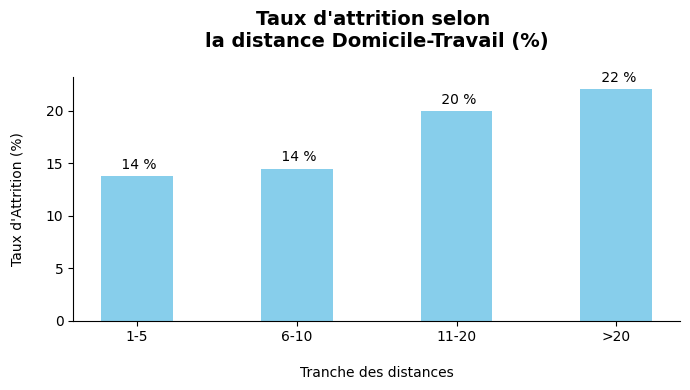

(None,)

In [30]:
fig, ax = plt.subplots(figsize=(7,4))

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

# Donnée
x = np.arange(len(pivot_distanceFromHome_attrition.index))
y = pivot_distanceFromHome_attrition['Yes']

# Barplot
bars = ax.bar(x, y, color="Skyblue", width=0.45)

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .0F} %'for v in y], padding=3)

# axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_distanceFromHome_attrition.index)
ax.set_xlabel("\nTranche des distances")
ax.set_ylabel("Taux d'Attrition (%)\n")
ax.set_title("Taux d'attrition selon \nla distance Domicile-Travail (%)\n", fontweight="bold", fontsize=14)
fig.tight_layout()
plt.show(),

On observe que le taux d'attrition est plus faible pour les employés habitant à moins de 10 km de leur lieu de travail, avec des valeurs comprises entre **13 % et 15 %**.  

En revanche, le taux d'attrition augmente avec la distance : elle atteint environ **20 %** pour la tranche **11-20 km** et dépasse **22 %** au delà de 20 km.

#### 3.2.4 Attrition et statut marital

Dans cette section, je compare l'attrition selon le statut marital afin d'observer si le taux d'attrition varie en fonction de la situation familiale des employés.

**Tableau de proportions**


In [31]:
# Tableau de proportion
maritalStatus_attrition = df_conditions_personnelles[["MaritalStatus", "Attrition"]]

## pivot : ligne = Statut marital, colonne= attrition, valeur =pourcentage
pivot_maritalStatus_attrition = pivot_percent(maritalStatus_attrition, "MaritalStatus","Attrition")
pivot_maritalStatus_attrition.sort_values("Yes",ascending=False)

Attrition,No,Yes
MaritalStatus,,
Single,74.5,25.5
Married,87.5,12.5
Divorced,89.9,10.1


On observe que les employés ayant le statut **Single** présentent le taux d'attrition le plus élevé (≈26 %).  

À l'inverse, les statuts **Married** et **Divorced** affichent des taux d'attrition plus faibles, compris entre **10 % et 13 %**.


#### 3.2.5 Attrition et niveau d'éducation

**Tableau de proportions**

In [32]:
# Tableau de proportion
education_attrition= df_conditions_personnelles[["Education_label", "Attrition"]]

## pivot : ligne = Niveau d'éducation, colonne= attrition, valeur =pourcentage
pivot_education_attrition = pivot_percent(education_attrition, "Education_label","Attrition")
pivot_education_attrition.sort_values("Yes", ascending=False)

Attrition,No,Yes
Education_label,,
Below College,81.8,18.2
Bachelor,82.7,17.3
College,84.4,15.6
Master,85.4,14.6
Doctor,89.6,10.4


On observe que le taux d'attrition varie selon le niveau d'éducation.  

Les niveaux **Below College** (≈18 %) et **Bachelor** (≈17 %) présentent les taux d'attrition les plus élevés.  

À l'inverse, le niveau **Doctor** affiche le taux d'attrition le plus faible (≈10 %).

Les niveaux **College** et **Master** se situent à un niveau intermédiaire, avec un taux d'attrition d'environ **15 %**.

#### 3.2.6 Attrition et domaine d'éducation

Dans cette section, je compare l'attrition selon le domaine d'éducation afin d'observer si le taux d'attrition varie en fonction de la spécialité académique des employés.

**Tableau de proportions**

In [33]:
# Tableau de proportion
educationfield_attrition= df_conditions_personnelles[["EducationField", "Attrition"]]

## pivot : ligne = Domaine d(éducation, colonne= attrition, valeur =pourcentage
pivot_educationfield_attrition = pivot_percent(educationfield_attrition, "EducationField","Attrition")
pivot_educationfield_attrition.sort_values("Yes", ascending=False)

Attrition,No,Yes
EducationField,,
Human Resources,74.1,25.9
Technical Degree,75.8,24.2
Marketing,78.0,22.0
Life Sciences,85.3,14.7
Medical,86.4,13.6
Other,86.6,13.4


On observe que le taux d'attrition est le plus élevé dans les domaines **Human Resources** (≈26 %) et **Technical Degree** (≈24 %).  

Le domaine **Marketing** présente également un taux d'attrition élevé (≈22 %), proche de ces deux catégories.

À l'inverse, les domaines **Life Sciences**, **Medical** et **Other** affichent des taux d'attrition plus faibles, compris entre **13 % et 15 %**.

#### 3.2.7 Attrition et genre

**Tableau de proportions**

In [34]:
# Tableau de proportion
genre_attritionn= df_conditions_personnelles[["Gender", "Attrition"]]

## pivot : ligne = genre, colonne= attrition, valeur =pourcentage
pivot_genre_attrition = pivot_percent(genre_attritionn, "Gender","Attrition")
pivot_genre_attrition.sort_values("Yes", ascending=False)

Attrition,No,Yes
Gender,,
Homme,83.0,17.0
Femme,85.2,14.8


On observe que le taux d'attrition est légèrement plus élevé chez les **hommes** (≈17 %) que chez les **femmes** (≈15 %).  
L'écart reste toutefois modéré, suggérant une différence limitée entre les deux groupes.

### 3.3 Résultats clés - Caractéristiques personnelles et attrition

Les analyses mettent en évidence plusieurs résultats structurants concernant la relation entre les caractéristiques personnelles des salariés et l'attrition.

- **L'âge apparaît comme un facteur fortement discriminant de l'attrition** : les salariés les plus jeunes (18-25 ans) présentent les taux de départ les plus élevés, tandis que les tranches d'âge intermédiaires (36-55 ans) affichent les niveaux d'attrition les plus faibles. Les groupes 26-35 ans et 55 ans et plus se situent à des niveaux intermédiaires.

- **La mobilité professionnelle passée est associée à des écarts marqués de taux d'attrition**. Les salariés ayant travaillé dans quatre entreprises ou plus présentent des taux d'attrition plus élevés, tandis que ceux ayant connu une mobilité modérée (2-3 entreprises) affichent les taux les plus faibles.

- **La distance domicile-travail influence également l'attrition** : les salariés résidant à proximité du lieu de travail présentent des taux plus faibles, tandis que l'attrition augmente progressivement avec l'éloignement géographique.

- **Le statut marital constitue un facteur différenciant**, les salariés célibataires affichant un taux d'attrition nettement plus élevé que les salariés mariés ou divorcés, dont les taux restent plus faibles et relativement proches.

- Les écarts d'attrition selon le niveau d'éducation restent globalement modérés, bien que les niveaux Below College et Bachelor présentent des taux légèrement plus élevés, tandis que le niveau Doctor affiche le taux le plus faible.

- **Le domaine de formation met en évidence des disparités plus marquées**, avec des taux d'attrition particulièrement élevés dans les domaines Human Resources, Technical Degree et Marketing, comparativement aux domaines Life Sciences, Medical et Other.

- Enfin, **les différences de taux d'attrition selon le genre demeurent limitées**, avec un niveau légèrement plus élevé chez les hommes que chez les femmes.

Une fois les comparaisons simples réalisées, j'explore les relations internes à l'axe afin d'identifier d'éventuels patterns ou corrélations.

## 4. Relations internes à l'axe conditions personnelles

---

### Introduction

Après avoir analysé les relations entre les variables personnelles et l'attrition, cette section vise à explorer les relations internes entre les variables de l'axe *Conditions personnelles*, afin d'identifier d'éventuelles associations ou configurations récurrentes.

Les analyses portent sur trois relations entre variables personnelles, étudiées dans le but d'apporter un éclairage complémentaire aux résultats d'attrition observés précédemment :

- Relation entre l'âge et la mobilité professionnelle  
- Relation entre l'âge et le statut marital  
- Relation entre la mobilité professionnelle et le statut marital  

Les variables sont analysées à partir de tableaux croisés (%) et de visualisations graphiques descriptives.

### 4.1 Relation entre l'âge et la mobilité professionnelle

Cette sous-section vise à observer la relation entre la variable *âge* et la *mobilité professionnelle*.

**Tableaux croisés (%)**


In [35]:
age_numCompaniesWorked = df_conditions_personnelles[["Tranche_Age", "Tranche_EtsTravaille"]]
age_numCompaniesWorked

# Pivot table : ligne = age, colonnes = Nombre entreprises travaillés, valeur = Pourcentage

pivot_age_numCompaniesWorked = pivot_percent(age_numCompaniesWorked, "Tranche_Age", "Tranche_EtsTravaille")
pivot_age_numCompaniesWorked

Tranche_EtsTravaille,0-1,2-3,4-6,+7
Tranche_Age,,,,
18-25,85.4,7.3,4.9,2.4
26-35,65.7,13.0,12.5,8.7
36-45,36.1,25.0,25.2,13.7
46-55,17.3,38.5,25.2,19.0
+55,14.9,27.7,31.9,25.5


**Visualisation**

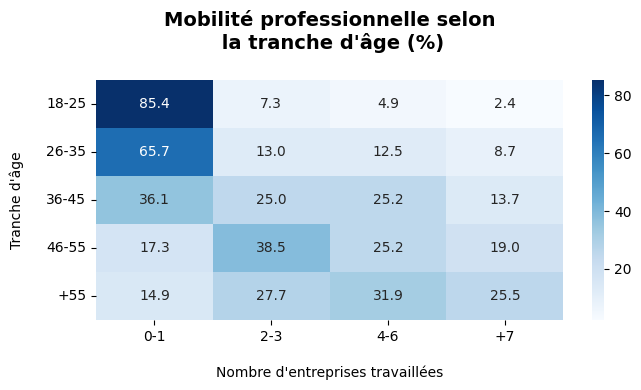

(None,)

In [36]:
# test heatmap

plt.figure(figsize=(7,4))

sns.heatmap(pivot_age_numCompaniesWorked, cmap="Blues", annot=True, fmt=".1f", cbar=True)

plt.gca().yaxis_inverted()
plt.title("Mobilité professionnelle selon\n la tranche d'âge (%)\n",fontsize=14, fontweight="bold" )
plt.xlabel("\nNombre d'entreprises travaillées")
plt.ylabel("Tranche d'âge\n")
plt.xticks(rotation= 0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show(),

On observe que les employés âgés de **18-25 ans** et **26-35 ans** présentent majoritairement une mobilité professionnelle faible, avec une proportion élevée d'employés ayant travaillé dans **0 à une entreprise** (≈85 % et ≈66 %).  

Cette proportion diminue progressivement avec l'augmentation du nombre d'entreprises travaillées.

Pour la tranche **36-45 ans**, la mobilité reste plus répartie, bien que la catégorie **0-une entreprise** demeure la plus représentée.

À l'inverse, les tranches d'âge **46-55 ans** et **+55 ans** présentent une mobilité professionnelle plus élevée.  
Chez les **46-55 ans**, la catégorie la plus fréquente correspond à **2-3 entreprises**, tandis que chez les **+55 ans**, la mobilité la plus représentée concerne **4-6 entreprises**.


### 4.2 Relation entre l'âge et le statut marital

Dans cette partie, cette session vise à observer la relation entre l'âge et le statut marital.

**Tableaux croisés (%)**

In [37]:
age_maritalStatus = df_conditions_personnelles[["Tranche_Age", "MaritalStatus"]]
age_maritalStatus

# Pivot table : ligne = Age, colonne = statut marital , valeur = pourcentage
pivot_age_maritalStatus = pivot_percent(age_maritalStatus,"Tranche_Age", "MaritalStatus")
pivot_age_maritalStatus

MaritalStatus,Divorced,Married,Single
Tranche_Age,,,
18-25,12.2,36.6,51.2
26-35,22.4,44.2,33.3
36-45,24.6,47.0,28.4
46-55,21.7,51.8,26.5
+55,25.5,48.9,25.5


**Visualisation**

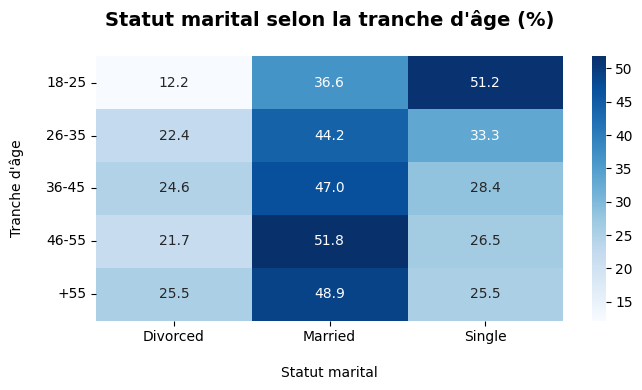

(None,)

In [38]:
# heatmap
plt.figure(figsize=(7,4))

sns.heatmap(pivot_age_maritalStatus, cmap="Blues", annot=True, fmt=".1F", cbar=True)
plt.gca().yaxis_inverted()

plt.xlabel("\nStatut marital")
plt.ylabel("Tranche d'âge\n")
plt.title("Statut marital selon la tranche d'âge (%)\n", fontsize=14, fontweight="bold")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show(),


On observe que la proportion d'employés ayant le statut **Married** augmente avec l'âge.  

Ce statut est majoritaire chez les **46-55 ans** (≈52 %) et les **+55 ans** (≈49 %).

À l'inverse, le statut **Single** est principalement représenté chez les **18-25 ans**, où il concerne plus de la moitié des employés (≈51 %), puis diminue progressivement avec l'âge.

Le statut **Divorced** présente une répartition relativement stable pour les tranches d'âge intermédiaires (entre **22 % et 26 %**), mais reste peu représenté chez les **18-25 ans** (≈12 %).


### 4.3 Relation entre la mobilité professionnelle et le statut marital

Dans cette section, j'observe la relation entre la mobilité professionnelle des employés et leur statut marital afin de compléter les deux analyses précédentes et d'identifier certains patterns.

**Tableaux croisés (%)**

In [39]:
numCompaniesWorked_maritalStatus = df_conditions_personnelles[["MaritalStatus", "Tranche_EtsTravaille"]]
numCompaniesWorked_maritalStatus

# Pivot table : ligne = Statut marital, colonne = Nombre entreprises travaillés , valeur = pourcentage
pivot_numCompaniesWorked_maritalStatus = pivot_percent(numCompaniesWorked_maritalStatus,"MaritalStatus", "Tranche_EtsTravaille")
pivot_numCompaniesWorked_maritalStatus

Tranche_EtsTravaille,0-1,2-3,4-6,+7
MaritalStatus,,,,
Divorced,44.3,21.1,22.3,12.2
Married,48.0,22.3,18.7,11.0
Single,53.2,18.3,15.5,13.0


**Visualisation**

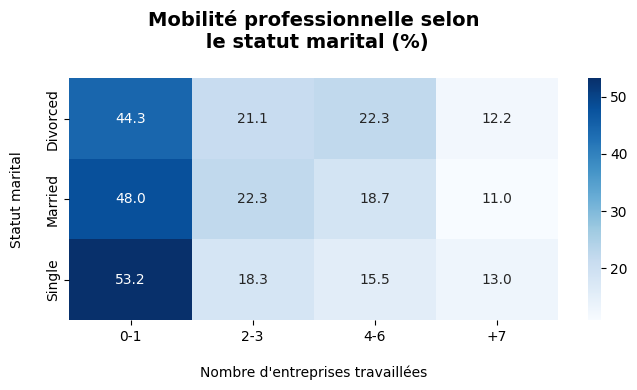

(None,)

In [40]:
# heatmap
plt.figure(figsize=(7, 4))

sns.heatmap(pivot_numCompaniesWorked_maritalStatus, cmap="Blues", fmt=".1F", annot=True)

plt.gca().yaxis_inverted()

plt.title("Mobilité professionnelle selon\n le statut marital (%)\n", fontsize=14, fontweight="bold")
plt.xlabel("\nNombre d'entreprises travaillées")
plt.ylabel("Statut marital\n")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show(),


On observe que, quel que soit le statut marital (**Single**, **Married** ou **Divorced**), les employés présentent majoritairement une mobilité professionnelle faible.  

La proportion d'employés ayant travaillé dans **0 à une entreprise** est élevée dans les trois groupes (≈53 %, ≈48 % et ≈44 %).

Cette proportion diminue progressivement avec l'augmentation du nombre d'entreprises précédemment travaillées, indiquant une structure de mobilité relativement similaire selon le statut marital.


Après avoir analysé ces trois relations, cette section synthétise les principaux patterns observés.

### 4.4 Synthèse des patterns observés

Les analyses des relations internes à l'axe *Conditions personnelles* mettent en évidence plusieurs patterns structurants :

- **Pattern 1 - Relation entre l'âge et la mobilité professionnelle**  
  La mobilité professionnelle augmente globalement avec l'âge.  
  Les tranches d'âge les plus jeunes présentent majoritairement une faible mobilité (0 à 1 entreprise), tandis que les tranches plus âgées sont davantage représentées dans les catégories de mobilité plus élevée.  
  Ce pattern suggère une évolution progressive des parcours professionnels au fil du temps.

- **Pattern 2 - Relation entre l'âge et le statut marital**  
  Le statut marital varie fortement selon l'âge.  
  Les employés les plus jeunes sont majoritairement **Single**, tandis que la proportion d'employés **Married** augmente nettement avec l'âge.  
  Cette relation met en évidence des logiques de parcours de vie au sein de la population étudiée.

- **Pattern 3 - Relation entre la mobilité professionnelle et le statut marital**  
  La mobilité professionnelle présente une structure relativement similaire quel que soit le statut marital.  
  Dans l'ensemble des groupes (**Single**, **Married**, **Divorced**), la mobilité faible reste majoritaire, suggérant que le statut marital n'est pas associé à des différences marquées de mobilité professionnelle dans ce jeu de données.

Ces patterns permettent de mieux contextualiser les résultats observés précédemment et servent de base à la synthèse globale de l'axe conditions personnelles.


## 5. Résultats clés 

---

- **Âge**  
  Les employés âgés de **moins de 25 ans** présentent le **taux d'attrition le plus élevé**, alors même que leur **mobilité professionnelle est faible**.  
  À l'inverse, les tranches d'âge plus élevées affichent des taux d'attrition plus faibles, malgré une mobilité professionnelle plus importante.

- **Distance domicile-travail**  
  Le taux d'attrition tend à **augmenter avec la distance domicile-travail**.  
  Toutefois, la majorité des employés résident à proximité de leur lieu de travail, ce qui limite l'impact global de ce facteur dans la population étudiée.

- **Mobilité professionnelle**  
  Les employés ayant une **mobilité professionnelle élevée** présentent des **taux d'attrition plus importants** que ceux ayant une mobilité faible ou modérée.  
  Ces profils correspondent majoritairement à des tranches d'âge plus élevées.

- **Statut marital**  
  Les employés ayant le statut **Single** affichent un **taux d'attrition plus élevé** que les employés **Married** ou **Divorced**.  
  Cette différence est particulièrement marqué chez les **employés de moins de 25 ans**, où le statut Single est majoritaire.


## 6. Conclusion de l'axe “Conditions personnelles”

---

L'étude de l'attrition doit donc être complétée par une analyse des **conditions de travail**, qui constituent des leviers d'action sur lesquels l'entreprise peut agir directement. Cet axe s'est concentré sur l'analyse des caractéristiques personnelles des employés (âge, genre, situation familiale, niveau et domaine d'éducation, distance domicile-travail, mobilité professionnelle).  

Ces facteurs individuels ne sont pas directement maîtrisables par l'entreprise, mais ils permettent de répondre à une première question descriptive essentielle : **qui quitte l'entreprise ?**

L'analyse des variables personnelles associées à l'attrition a permis de mettre en évidence que certains profils présentent des taux d'attrition plus élevés que d'autres, sans logique de stigmatisation individuelle.  
Certaines caractéristiques personnelles sont associées à des différences de taux d'attrition et contribuent à structurer des profils distincts au sein de la population étudiée.

Toutefois, l'analyse isolée de ces variables reste insuffisante sans prise en compte du contexte organisationnel. 
 
L'étude de l'attrition doit donc être complétée par une analyse des **conditions de travail**, qui constituent des leviers d'action sur lesquels l'entreprise peut agir directement.



